## **SPHERE FUNCTION - 1D**

In [2]:
def func(x):
    return x**2

def derivative(x):
    return 2*x

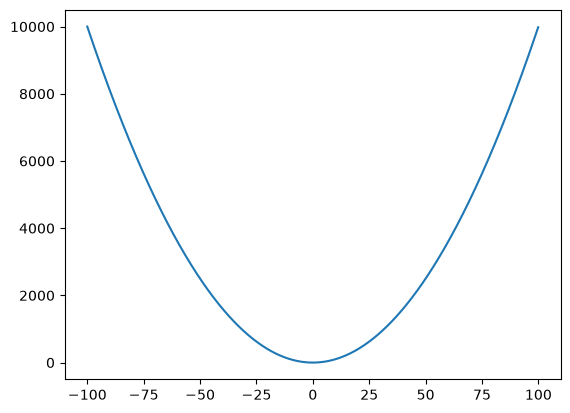

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-100, 100, 0.1)
y = func(x)

plt.plot(x,y)
plt.show()

In [4]:
import random

num_steps = 10
step = 1
lr = 0.1

#1. set x randomly
x = random.randint(-100, 100)
print(x)

for _ in range(num_steps):
    #compute derivative
    dx = derivative(x)

    #update
    x = x - lr*dx
    print(x, func(x))

47
37.6 1413.7600000000002
30.080000000000002 904.8064000000002
24.064 579.076096
19.2512 370.60870144
15.400960000000001 237.18956892160003
12.320768000000001 151.80132410982404
9.856614400000002 97.1528474302874
7.885291520000001 62.177822355383924
6.3082332160000005 39.793806307445706
5.046586572800001 25.46803603676526


## **SPHERE FUNCTION - 2D**

In [6]:
#sphere function
def func(x,y):
    return x**2 + y**2

#gradient
def gradient(x, y):
    dx = 2*x
    dy = 2*y
    return dx, dy

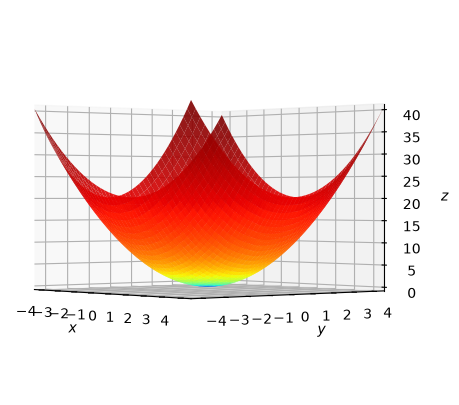

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm

xmin, xmax, xstep = -4.5, 4.5, .2
ymin, ymax, ystep = -4.5, 4.5, .2

x, y = np.meshgrid(np.arange(xmin, xmax + xstep, xstep), np.arange(ymin, ymax + ystep, ystep))

z = func(x,y)

##3D surface plot
fig = plt.figure(figsize=(8,5))
ax = plt.axes(projection='3d', elev = 0, azim=-40)

ax.plot_surface(x,y,z,norm=LogNorm(), rstride=1, cstride=1,
                edgecolor='none', alpha=.9, cmap=plt.cm.jet)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

ax.set_xlim((xmin, xmax))
ax.set_ylim((ymin, ymax))

plt.show()

In [8]:
#set (x,y) randomly
x = random.randint(-100,100)
y = random.randint(-100,100)
print(x,y)

#params
num_iterations = 10
step = 1
lr = 0.1

#optimize
for _ in range(num_iterations):
    #compute the derivative at (x,y)
    dx, dy = gradient(x,y)

    #update
    x = x - lr*dx
    y = y - lr*dy

    print(x,y,func(x,y))

100 53
80.0 42.4 8197.76
64.0 33.92 5246.5664
51.2 27.136000000000003 3357.8024960000007
40.96 21.708800000000004 2148.9935974400005
32.768 17.367040000000003 1375.3559023616
26.2144 13.893632000000002 880.227777511424
20.97152 11.114905600000002 563.3457776073114
16.777216000000003 8.891924480000002 360.5412976686794
13.421772800000003 7.1135395840000015 230.74643050795484
10.737418240000002 5.690831667200001 147.6777155250911


## **COMPOSITE FUNCTION**

In [9]:
'''
f(x) = 2x-1
g(f) = (f-3)^2
'''

def fx(x):
    return 2*x - 1

def df_dx(x):
    return 2

def gf(f):
    return (f-3)**2

def dg_df(f):
    return 2*(f-3)

#compute g_x
def forward(x):
    fx_value = fx(x)
    gf_value = gf(fx_value)
    return gf_value

#compute dg_x
def backward(x, fx_value):
    df_dx_value = df_dx(x)
    dg_df_value = dg_df(df_dx_value)
    dg_dx_value = df_dx_value*dg_df_value
    return dg_dx_value


In [10]:
#minimize the composite function g(f(x))

num_steps = 20
lr = 0.1

#1. set x randomly
x = random.randint(-100, 100)
print(x)

for _ in range(num_steps):
    #1. compute derivative
    fx_value = fx(x)
    dg_dx_value = backward(x, fx_value)

    #2. update
    x = x - lr*dg_dx_value
    print(x, ' ', forward(x))

8
8.4   163.84000000000003
8.8   184.96000000000004
9.200000000000001   207.36000000000007
9.600000000000001   231.04000000000008
10.000000000000002   256.0000000000001
10.400000000000002   282.2400000000001
10.800000000000002   309.76000000000016
11.200000000000003   338.56000000000023
11.600000000000003   368.64000000000027
12.000000000000004   400.0000000000003
12.400000000000004   432.6400000000003
12.800000000000004   466.56000000000034
13.200000000000005   501.7600000000004
13.600000000000005   538.2400000000005
14.000000000000005   576.0000000000005
14.400000000000006   615.0400000000005
14.800000000000006   655.3600000000006
15.200000000000006   696.9600000000007
15.600000000000007   739.8400000000007
16.000000000000007   784.0000000000008


In [12]:
##More compact

'''
f(x) = 2x - 1
g(f) = (f-3)^2

g'(x) = 8x - 16
''' 
def fx(x):
    return 2*x - 1

def gf(f):
    return (f-3)**2

def dg_dx(x):
    return 8*x - 16

In [13]:
num_steps = 5
lr = 0.1

# 1. set x randomly
x = random.randint(-100, 100)
print(x)

for _ in range(num_steps):
    # 2. compute g(f(x))
    loss = gf(fx(x))
    
    # print
    print(f'x={x} and g(x)={loss}')
    
    # 3. compute derivative
    dg_dx_value = dg_dx(x)
            
    # 4. update
    x = x - lr*dg_dx_value  

74
x=74 and g(x)=20736
x=16.4 and g(x)=829.4399999999998
x=4.879999999999999 and g(x)=33.17759999999998
x=2.5759999999999996 and g(x)=1.3271039999999983
x=2.1151999999999997 and g(x)=0.05308415999999977


## **DATA STOCHASTIC**

In [14]:
#load a csv file

data = np.genfromtxt('data.csv', delimiter=',')
print(data)

[[6.7 9.1]
 [4.6 5.9]
 [3.5 4.6]
 [5.5 6.7]]


In [16]:
#get a column from a 2D list

#test
data = np.genfromtxt('data.csv', delimiter=',')

#get column index = 0
columm0 = data[:,0]
print(columm0)

#get column index = 1
columm1 = data[:,1]
print(columm1)

[6.7 4.6 3.5 5.5]
[9.1 5.9 4.6 6.7]


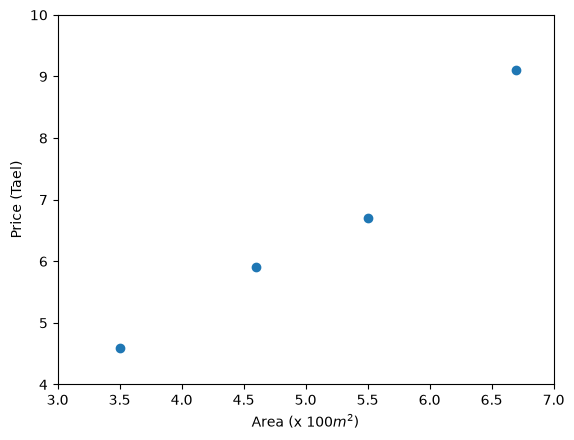

In [17]:
#load data and plot

areas = data[:,0]
prices = data[:,1]
N = len(areas)

plt.scatter(areas, prices)
plt.xlabel('Area (x 100$m^2$)')
plt.ylabel('Price (Tael)')
plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

In [18]:
### IMPLEMENTATION

#forward
def predict(x, w, b):
    return x*w + b

#compute gradient
def gradient(y_hat, y, x):
    dw = 2*x*(y_hat-y)
    db = 2*(y_hat-y)
    return (dw, db)


#update weights
def update_weight(w, b, lr, dw, db):
    w_new = w - lr*dw
    b_new = b - lr*db
    return(w_new, b_new)

In [19]:
#data preparation

x_data = data[:,0]
y_data = data[:,1]
N = data.shape[0]

print(f'areas: {x_data}')
print(f'prices: {y_data}')
print(f'data_size: {N}')

areas: [6.7 4.6 3.5 5.5]
prices: [9.1 5.9 4.6 6.7]
data_size: 4


In [20]:
#init weights
b = 0.04
w = -0.34
lr = 0.02

#parameter
epoch_max = 10
losses = [] #for debug

for epoch in range(epoch_max):

    #for an epoch
    for i in range(N):

        #get a sample
        x = x_data[i]
        y = y_data[i]

        #predict y_hat
        y_hat = predict(x,w,b)

        #compute loss
        loss = (y_hat-y)**2

        #for debug
        losses.append(loss)
        print(loss)

        #compute gradient
        (dw, db) = gradient(y_hat, y, x)

        #update weights
        (w, b) = update_weight(w,b,lr, dw,db)

128.550244
49.09813868964093
0.2978666638171294
0.6761546819648765
1.4961961729515123
1.2421558961808372
0.0005958270445172143
0.20619980459758444
1.227290769192806
1.0862982111039632
0.00020202921498897256
0.20772372381330653
1.2206101856626983
1.072086600947402
9.585957527677484e-05
0.21303364196383398
1.2167572802447408
1.0595691504116764
2.984811025072228e-05
0.2184154503006066
1.2129687722154336
1.047230121315139
1.36272760749999e-06
0.22382593527869668
1.2092133726087544
1.0350504441855346
9.598186231460192e-06
0.22926347757442328
1.2054904186072315
1.02302778720548
5.377644012572535e-05
0.23472695224819373
1.2017995942617465
1.0111600347032241
0.00013313238164334098
0.24021526082354577
1.1981405908472518
0.9994451022376798
0.0002469135567324983
0.24572732563292451


In [21]:
#get result
print(w,b)

1.192491163985917 0.017371370027855694


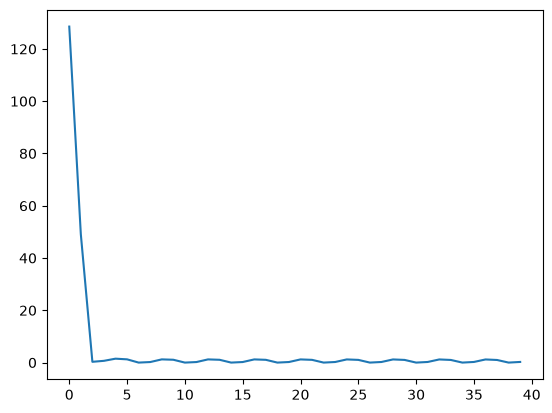

In [22]:
import matplotlib.pyplot as plt
plt.plot(losses) 

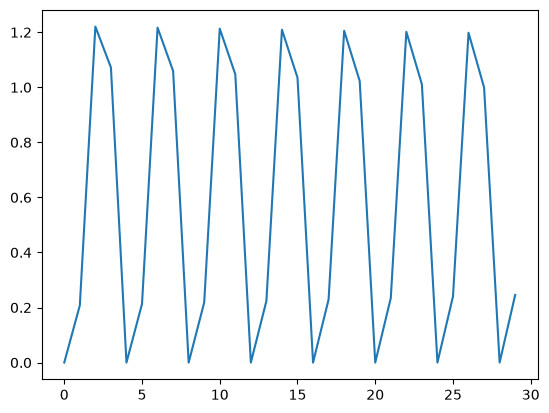

In [23]:
import matplotlib.pyplot as plt
plt.plot(losses[10:]) 

In [24]:
area_real = 6
w = 1.212
b = 0.225
predicted_price = area_real*w + b
print('predicted_price: ', predicted_price)

predicted_price:  7.497


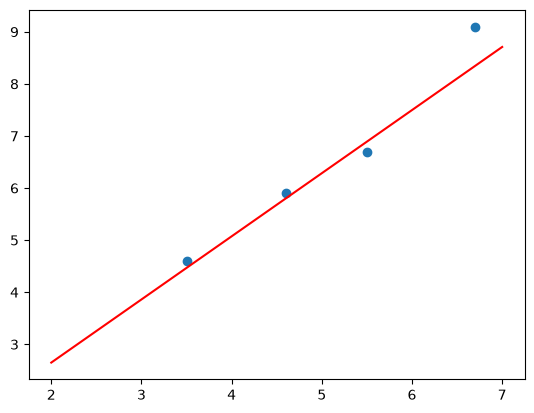

In [25]:
x_data = range(2, 8)
y_data = [x*w + b for x in x_data]
plt.plot(x_data, y_data, 'r')

data = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0]
prices = data[:,1]
plt.scatter(areas, prices)

## **ADVERTISING STOCHASTIC**

In [1]:
# load a cvs file
import numpy as np

# tv, radio, newspaper, sales
data = np.genfromtxt('advertising.csv', delimiter=',')
print(data[:5])

[[  nan   nan   nan   nan]
 [230.1  37.8  69.2  22.1]
 [ 44.5  39.3  45.1  10.4]
 [ 17.2  45.9  69.3  12. ]
 [151.5  41.3  58.5  16.5]]


In [2]:
# load a cvs file
import numpy as np

data = np.genfromtxt('advertising.csv', delimiter=',', skip_header=1)
print(data[:5])

[[230.1  37.8  69.2  22.1]
 [ 44.5  39.3  45.1  10.4]
 [ 17.2  45.9  69.3  12. ]
 [151.5  41.3  58.5  16.5]
 [180.8  10.8  58.4  17.9]]


In [3]:
##implementation

#dataset
import numpy as np
import matplotlib.pyplot as plt
import random

data = np.genfromtxt('advertising.csv', delimiter=',', skip_header=1)
N = data.shape[0]

# get tv (index=0)
tv_data = data[:,0]
print(tv_data[:5])

# get radio (index=1)
radio_data = data[:,1]
print(radio_data[:5])

# get newspaper (index=2)
newspaper_data = data[:,2]
print(newspaper_data[:5])

# get sales (index=0)
sales_data = data[:,3]
print(sales_data[:5])

[230.1  44.5  17.2 151.5 180.8]
[37.8 39.3 45.9 41.3 10.8]
[69.2 45.1 69.3 58.5 58.4]
[22.1 10.4 12.  16.5 17.9]


In [4]:
#compute output and loss
def predict (x1, x2, x3, w1, w2, w3, b):
    return w1*x1 + w2*x2 + w3*x3 + b

def compute_loss(y_hat, y):
    return (y_hat - y)**2

# compute gradient
def compute_gradient_wi(xi, y, y_hat):
    dl_dwi = 2*xi*(y_hat-y)
    return dl_dwi 

def compute_gradient_b(y, y_hat):
    dl_db = 2*(y_hat-y)
    return dl_db

# update weights
def update_weight_wi(wi, dl_dwi, lr):
    wi = wi - lr*dl_dwi
    return wi    
    
def update_weight_b(b, dl_db, lr):    
    b  = b - lr*dl_db    
    return b

In [5]:
def initialize_params():
    w1 = random.gauss(mu=0.0, sigma=0.01)
    w2 = random.gauss(mu=0.0, sigma=0.01)
    w3 = random.gauss(mu=0.0, sigma=0.01)
    b  = 0
    
    return w1, w2, w3, b

# initialize model's parameters
w1, w2, w3, b = initialize_params()
print(w1, w2, w3, b)

-0.008327263778814023 -0.010528587840091768 -0.009506481262999937 0


In [6]:
epoch_max = 50
lr = 1e-5
losses = []

for epoch in range(epoch_max):
    for i in range(N):
        # get a sample
        x1 = tv_data[i]
        x2 = radio_data[i]
        x3 = newspaper_data[i]
        y  = sales_data[i]
        
        # compute output 
        y_hat = predict(x1, x2, x3, w1, w2, w3, b)
        
        # compute loss
        loss = compute_loss(y, y_hat)

        # compute gradient w1, w2, w3, b
        dl_dw1 = compute_gradient_wi(x1, y, y_hat)
        dl_dw2 = compute_gradient_wi(x2, y, y_hat)
        dl_dw3 = compute_gradient_wi(x3, y, y_hat)
        dl_db  = compute_gradient_b(y, y_hat)


        # update parameters
        w1 = update_weight_wi(w1, dl_dw1, lr)
        w2 = update_weight_wi(w2, dl_dw2, lr)
        w3 = update_weight_wi(w3, dl_dw3, lr)
        b  = update_weight_b(b, dl_db, lr)

        # logging
        losses.append(loss) 

<function matplotlib.pyplot.show(close=None, block=None)>

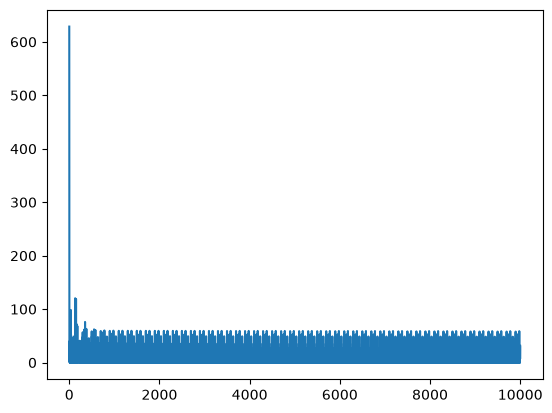

In [7]:
plt.plot(losses)
plt.show

In [8]:
##inference
# get model's parameters
print(w1, w2, w3, b)

0.07405883624656515 0.15917101398993977 0.017560033102343862 0.13948038703835375


In [9]:
def predict(x1, x2, x3, w1, w2, w3, b):
    return w1*x1 + w2*x2 + w3*x3 + b

# given new data
tv = 19.2
radio = 35.9 
newspaper = 51.3

sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 8.176479143361483


In [10]:
# [230.1, 37.8, 69.2, 22.1]

tv = 230.1
radio = 37.8 
newspaper = 69.2

sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 24.41223722687491


## **ONE SAMPLE VECTORISATION**

In [11]:
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt

data = genfromtxt('data.csv', delimiter=',')
N = 4
theta = np.array([0.049, -0.34])

areas  = data[:, 0].reshape(1, N)
ys = data[:, 1].reshape(N,)

X = np.vstack([np.ones((1, N)), areas]) # each sample is a column
print(X)
print(ys)

# try (each sample is a row)
#areas = data[:, 0].reshape(N, 1)
#areas = np.hstack([areas, np.ones((N, 1))])

[[1.  1.  1.  1. ]
 [6.7 4.6 3.5 5.5]]
[9.1 5.9 4.6 6.7]


In [12]:
def predict(x, theta):
    return x.T.dot(theta) # theta.T.dot(x)

def compute_loss(y_hat, y):
    return (y_hat-y)*(y_hat-y)

def compute_gradient(y_hat, y, x):
    return 2*x*(y_hat-y)

def update_weight(theta, lr, dtheta):
    return theta - lr*dtheta

In [13]:
lr = 0.01

losses = []
for _ in range(10):
    for i in range(N):
        # get a sample
        x = X[:, i]
        y = ys[i]

        y_hat = predict(x, theta)
        loss = compute_loss(y_hat, y)
        losses.append(loss)

        dtheta = compute_gradient(y_hat, y, x)
        theta = update_weight(theta, lr, dtheta)

    
# done
print(theta)

[0.2335058  1.21100306]


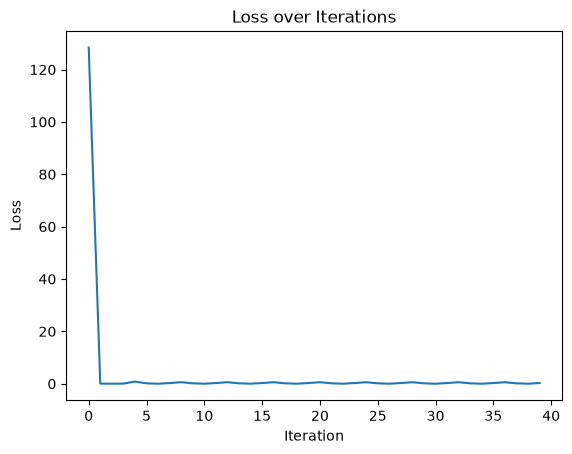

In [14]:
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.show()


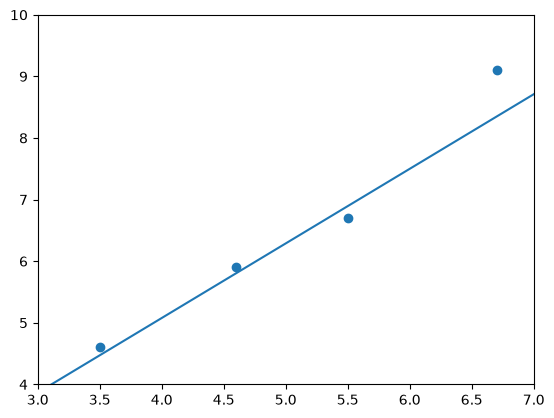

In [15]:
x_data = range(2, 8)

predicted_b, predicted_w = theta
y_data = [x*predicted_w + predicted_b for x in x_data]
plt.plot(x_data, y_data)
#--------------------------------------
plt.scatter(areas, ys)
plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

## **ADVERTISING VECTORISATION**

In [16]:
# dataset
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt

data = genfromtxt('advertising.csv', delimiter=',', skip_header=1)

N = data.shape[0]
X = data[:,:3]
y = data[:,3:]

X_b = np.hstack((np.ones((N, 1)), X))

In [17]:
print(X_b.shape)
print(X_b[:5])

(200, 4)
[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]
 [  1.   17.2  45.9  69.3]
 [  1.  151.5  41.3  58.5]
 [  1.  180.8  10.8  58.4]]


In [18]:
print(y.shape)
print(y[:5])

(200, 1)
[[22.1]
 [10.4]
 [12. ]
 [16.5]
 [17.9]]


In [19]:
n_epochs = 50
learning_rate = 0.00001

# khởi tạo giá trị tham số
thetas = np.random.randn(4, 1)

thetas_path = [thetas]
losses = []

for epoch in range(n_epochs):
    for i in range(N):
        # lấy 1 sample            
        xi = X_b[i]        
        xi = np.reshape(xi, (4, 1)) # giả lập vector cột bằng matrix 4x1
        yi = y[i:i+1]

        # tính output 
        y_hat = xi.T.dot(thetas)

        # tính loss li
        li = (y_hat - yi)*(y_hat - yi)

        # tính gradient cho loss
        g_li = 2*(y_hat - yi)

        # tính gradient 
        gradients = xi*g_li

        # update giá trị theta
        thetas = thetas - learning_rate*gradients

        # logging
        thetas_path.append(thetas)            
        losses.append(li[0][0])

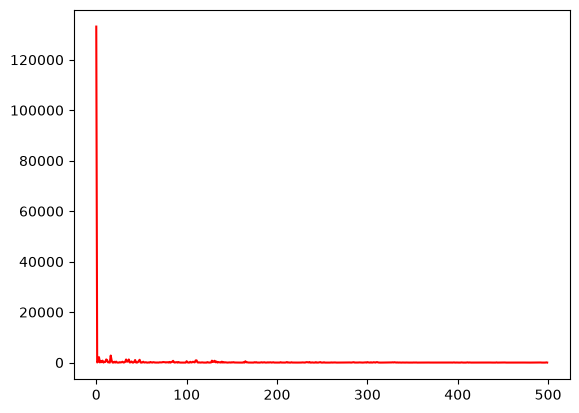

In [20]:
import matplotlib.pyplot as plt
# in loss cho 500 sample đầu
x_axis = list(range(500))
plt.plot(x_axis,losses[:500], color="r")
plt.show()